In [41]:
# @title
# FBR
# We Need More Butterflies - FBR
import os
import sys
import importlib
import warnings

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

project_path = '/content/drive/MyDrive/UC/ACA/ACA_P2_FBR'

os.chdir(project_path)

if project_path not in sys.path:
    sys.path.append(project_path)
diretorio_imagens_sinteticas = os.path.join(project_path, 'dataset_entrega_N3')

print(f"Diretório atualizado: {os.getcwd()}")

!pip install -q kagglehub==1.0.0
!pip install -q torchmetrics[image]==1.4.0.post0

import torch
import torch.nn as nn

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

import kagglehub

from sklearn.model_selection import train_test_split

from torchvision import transforms

from torch.utils.data import DataLoader

from torchvision.utils import save_image

import config
import models
import pipelines

from config import ProjectConfig as cfg
from models import (ButterflyDataset, BaselineCNN, ButterflyAutoencoder64, Generator64, Discriminator64)
from pipelines import (train_classifier, train_autoencoder, train_pure_gan)

print("Módulos carregados com sucesso!")

torch.manual_seed(cfg.SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.SEED)

warnings.filterwarnings("ignore", category=UserWarning)

os.environ["PYTHONWARNINGS"] = "ignore"

Mounted at /content/drive
Diretório atualizado: /content/drive/MyDrive/UC/ACA/ACA_P2_FBR
Módulos carregados com sucesso!


In [42]:
import config
import models
import pipelines

from config import ProjectConfig as cfg
from models import (ButterflyDataset, BaselineCNN, ButterflyAutoencoder64, Generator64, Discriminator64, ButterflyVAE64)
from pipelines import (evaluate_model,train_classifier, train_autoencoder, train_pure_gan, train_vae, gerar_samples, avaliar_metricas_por_classe)

In [43]:
importlib.reload(config)
importlib.reload(models)
importlib.reload(pipelines)

<module 'pipelines' from '/content/drive/MyDrive/UC/ACA/ACA_P2_FBR/pipelines.py'>

In [5]:
# @title
print("Autenticando no Kaggle...")

try:
    kagglehub.login('KGAT_060abfadf45750ce17bc30a7390a24ea')
except Exception as e:
    print("Erro ao abrir login automático.")

print("Baixando dados...")



Autenticando no Kaggle...


Baixando dados...
Kaggle credentials set.


In [6]:
# @title
path = kagglehub.competition_download('aca-tp-2')

img_dir = os.path.join(path, 'train')

df_full = pd.read_csv(
    os.path.join(path, 'train.csv')
)

print(f"Dataset carregado de: {path}")

Dataset carregado de: /root/.cache/kagglehub/competitions/aca-tp-2


--- As 10 classes com MENOS amostras no dataset ---
label
MOURNING CLOAK    105
SLEEPY ORANGE      85
ATALA              80
BROWN SIPROETA     79
ORANGE TIP         77
Name: count, dtype: int64
label
AMERICAN SNOOT    59
CRIMSON PATCH     58
MALACHITE         58
GOLD BANDED       58
WOOD SATYR        57
Name: count, dtype: int64


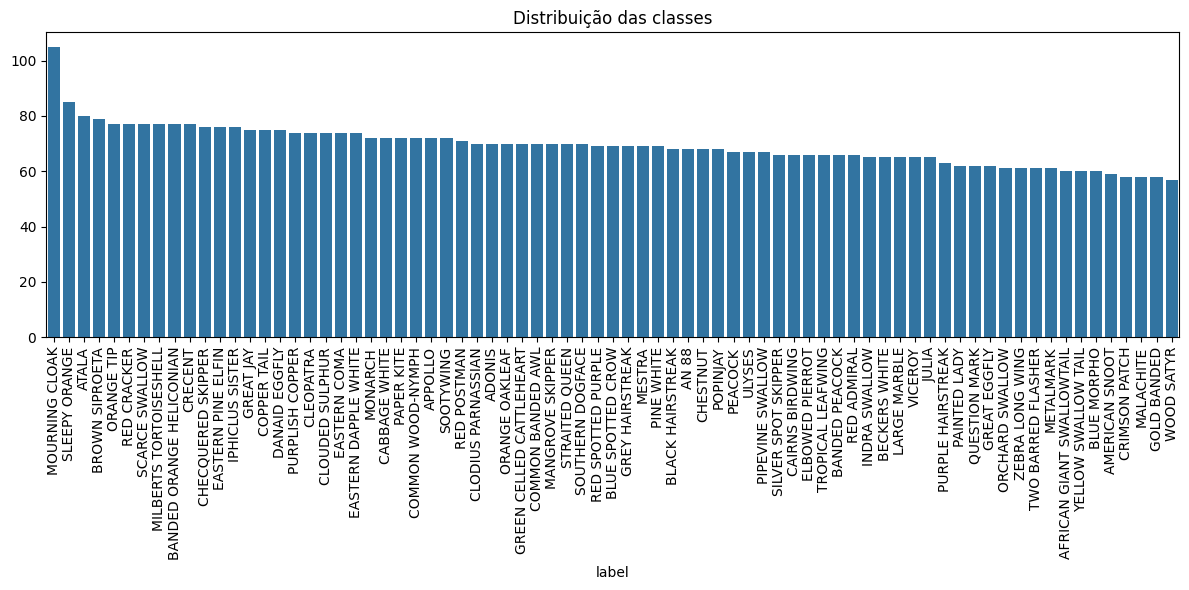

In [9]:
# @title
# Iidentificar os alvos ideais de geração
class_counts = df_full['label'].value_counts()
print("--- As 10 classes com MENOS amostras no dataset ---")
print(class_counts.head(5))
print(class_counts.tail(5))

# Salvar o gráfico para a seção de Dataset do relatório
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.barplot(x=class_counts.index[:75], y=class_counts.values[:75])
plt.title("Distribuição das classes")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Avaliando o Dataset, talvez focar em tratar as 3 classes com menor representação. Checaremos novamente após o treino baseline e validação.

In [7]:
# @title
# 15% reservado exclusivamente para teste final
df_temp, df_test = train_test_split(
    df_full, test_size=0.15, stratify=df_full['label'], random_state=cfg.SEED)

# 70% treino / 15% validação
df_train, df_val = train_test_split(df_temp, test_size=0.1765, stratify=df_temp['label'], random_state=cfg.SEED)

print("=== Divisão de Dados Concluída ===")

print(f"Treino:    {len(df_train)} imagens (~70%)")
print(f"Validação: {len(df_val)} imagens (~15%)")
print(f"Teste:     {len(df_test)} imagens (~15%)")

train_transform = transforms.Compose([
    transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(15), # adicionado no RandomAffine
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomAffine(degrees=15, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    transforms.ToTensor()
])

# GAN usa normalização simétrica [-1, 1]
gan_transform = transforms.Compose([
    transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize( [0.5] * 3, [0.5] * 3)
])

train_dataset = ButterflyDataset(df=df_train, img_dir=img_dir, transform=train_transform)

val_dataset = ButterflyDataset(df=df_val, img_dir=img_dir, transform=val_transform)

test_dataset = ButterflyDataset(df=df_test, img_dir=img_dir, transform=val_transform)

usar_pin_memory = cfg.DEVICE.type == "cuda"

train_loader = DataLoader(train_dataset,batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS, pin_memory=usar_pin_memory)

val_loader = DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=usar_pin_memory)

test_loader = DataLoader(test_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=usar_pin_memory)



gan_dataset = ButterflyDataset(df=df_train, img_dir=img_dir, transform=gan_transform)

gan_loader = DataLoader(gan_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True, num_workers=cfg.NUM_WORKERS, pin_memory=usar_pin_memory)

print("\nDataLoaders criados com sucesso!")

=== Divisão de Dados Concluída ===
Treino:    3639 imagens (~70%)
Validação: 780 imagens (~15%)
Teste:     780 imagens (~15%)

DataLoaders criados com sucesso!


In [95]:
# @title
# Carregar/Treinar Baseline
print("=== BASELINE CNN ===")

# n_classes = len(dataset.classes)
model_baseline = BaselineCNN(num_classes=cfg.NUM_CLASSES).to(cfg.DEVICE)
optimizer = torch.optim.Adam(model_baseline.parameters(), lr=cfg.CNN_LR) ### lr=0.001
criterion = nn.CrossEntropyLoss()

model_baseline, baseline_history, best_val_acc, baseline_test_acc = train_classifier(
    model_baseline, train_loader, val_loader, test_loader, optimizer, criterion, cfg)

print("\n=== RESULTADO BASELINE ===")

print(f"Melhor Val Acc: {best_val_acc:.4f}")

print(f"Test Acc: {baseline_test_acc:.4f}")

=== BASELINE CNN ===

[INFO] Checkpoint 'best_classifier.pth' encontrado! Carregando pesos existentes...
[INFO] Avaliando modelo carregado no conjunto de teste local...
[TEST] Loss: 0.6399 | Acc: 83.46%


=== RESULTADO BASELINE ===
Melhor Val Acc: 0.8346
Test Acc: 0.8346


In [10]:
# @title
# Entendendo as deficiencias do baseline
from sklearn.metrics import classification_report

def diagnosticar_baseline_real(model_path, test_loader, device, class_names):
    # 1. Instancia a arquitetura e carrega os pesos salvos do melhor modelo
    # (Ajuste o nome da classe 'BaselineCNN' se a sua tiver outro nome no arquivo)
    from models import BaselineCNN

    model = BaselineCNN(num_classes=len(class_names)).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    all_preds = []
    all_targets = []

    print("[INFO] Avaliando o melhor modelo no test_loader...")
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.numpy())

    # 2. Gera o relatório de métricas por classe
    report = classification_report(all_targets, all_preds, target_names=class_names, output_dict=True)
    df_report = pd.DataFrame(report).transpose()

    # Isola apenas as linhas das classes reais
    df_classes = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')

    # Ordena pelo F1-Score de forma crescente (as piores primeiro)
    piores_classes = df_classes.sort_values(by='f1-score', ascending=True).head(5)

    print("\n" + "="*60)
    print("AS 5 CLASSES MAIS SOFRIDAS NO BASELINE PURO")
    print("="*60)
    for idx, (classe, row) in enumerate(piores_classes.iterrows(), 1):
        print(f"{idx}. {classe}  | Precision: {row['precision']:.4f} | Recall: {row['recall']:.4f} | F1-Score: {row['f1-score']:.4f} | Amostras no Teste (Suporte): {int(row['support'])}")

    return df_classes

# --- EXECUÇÃO DO DIAGNÓSTICO ---
# Garante a ordenação alfabética idêntica à usada na inicialização do dataset original
nomes_das_classes = sorted(df_train['label'].unique())

# Executa passando o caminho do seu arquivo de pesos salvo
df_resultado = diagnosticar_baseline_real(
    model_path='best_classifier.pth',
    test_loader=test_loader,
    device=cfg.DEVICE,
    class_names=nomes_das_classes
)

[INFO] Avaliando o melhor modelo no test_loader...

AS 5 CLASSES MAIS SOFRIDAS NO BASELINE PURO
1. TROPICAL LEAFWING  | Precision: 0.2667 | Recall: 0.4000 | F1-Score: 0.3200 | Amostras no Teste (Suporte): 10
2. COPPER TAIL  | Precision: 0.4286 | Recall: 0.2727 | F1-Score: 0.3333 | Amostras no Teste (Suporte): 11
3. QUESTION MARK  | Precision: 0.6000 | Recall: 0.3333 | F1-Score: 0.4286 | Amostras no Teste (Suporte): 9
4. COMMON BANDED AWL  | Precision: 0.5000 | Recall: 0.5000 | F1-Score: 0.5000 | Amostras no Teste (Suporte): 10
5. CLOUDED SULPHUR  | Precision: 0.5385 | Recall: 0.6364 | F1-Score: 0.5833 | Amostras no Teste (Suporte): 11


Entendendo que as 3 classes mais prejudicadas sao as de menor F1-Score. Concentraremos esforços em melhorar estas 3 classes: Tropical Leafwing, Copper Tail e Question Mark.

Negativo, última forma. Imagens borrosas nao vao salvar F1-Score, vao salvar na classificacao geral. Voltando a focar nas de menor representação: **['GOLD BANDED', 'MALACHITE', 'CRIMSON PATCH']** -- todas gerando 47 imagens.

In [8]:
# @title
# Preparando tudo para isolar os datasets que serao aumentados.

classes_alvo = ['GOLD BANDED', 'MALACHITE', 'CRIMSON PATCH']

train_loaders_ae = {}
orig_loaders_ae = {}
val_loaders_ae = {}
test_loaders_ae = {}

for cls in classes_alvo:
    # Isolando as classes
    df_cls_train = df_train[df_train['label'] == cls].reset_index(drop=True)
    df_cls_val   = df_val[df_val['label'] == cls].reset_index(drop=True)
    df_cls_test  = df_test[df_test['label'] == cls].reset_index(drop=True)

    # Instanciando os Datasets especificos das classes
    ds_cls_train = ButterflyDataset(df=df_cls_train, img_dir=img_dir, transform=train_transform)
    ds_cls_orig = ButterflyDataset(df=df_cls_train,   img_dir=img_dir, transform=val_transform)
    ds_cls_val   = ButterflyDataset(df=df_cls_val,   img_dir=img_dir, transform=val_transform)
    ds_cls_test  = ButterflyDataset(df=df_cls_test,  img_dir=img_dir, transform=val_transform)

    # Criando os DataLoaders das classes
    # min/max e drop_last=False garantem que nenhuma imagem seja descartada devido ao tamanho reduzido dos lotes (temos pouco)
    train_loaders_ae[cls] = DataLoader(
        ds_cls_train,
        batch_size=min(cfg.BATCH_SIZE, len(df_cls_train)),
        shuffle=True,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=True,
        drop_last=False
    )

    orig_loaders_ae[cls] = DataLoader(
        ds_cls_orig,
        batch_size=max(1, len(df_cls_val)),
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=True,
        drop_last=False
    )
    val_loaders_ae[cls] = DataLoader(
        ds_cls_val,
        batch_size=max(1, len(df_cls_val)),
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=True,
        drop_last=False
    )

    test_loaders_ae[cls] = DataLoader(
        ds_cls_test,
        batch_size=max(1, len(df_cls_test)),
        shuffle=False,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=True,
        drop_last=False
    )

    print(f"Classe: {cls:<15} | Treino: {len(df_cls_train):<3} | Val: {len(df_cls_val):<2} | Teste: {len(df_cls_test):<2}")

print("Loaders de Treino, Validação e Teste foram isolados com sucesso.")



Classe: GOLD BANDED     | Treino: 40  | Val: 9  | Teste: 9 
Classe: MALACHITE       | Treino: 40  | Val: 9  | Teste: 9 
Classe: CRIMSON PATCH   | Treino: 40  | Val: 9  | Teste: 9 
Loaders de Treino, Validação e Teste foram isolados com sucesso.


In [159]:
##### Treinando o AE

print("=== INICIANDO PIPELINE DE TREINAMENTO DO AUTOENCODER ===")

# Dicionário global que ACUMULA os históricos
ae_histories = {}

for cls in classes_alvo:
    print("\n" + "="*70)
    print(f" PROCESSANDO CLASSE: {cls}")
    print("="*70)

    print(f"\n[AE] Inicializando ButterflyAutoencoder64 para {cls}...")
    model_ae = ButterflyAutoencoder64(color_channels=3).to(cfg.DEVICE)
    optimizer_ae = torch.optim.Adam(model_ae.parameters(), lr=cfg.AE_LR)

    # Chamada corrigida: retorna ae_history (singular) e salva no dicionário (plural)
    model_ae, ae_history = train_autoencoder(
        model=model_ae,
        train_loader=train_loaders_ae[cls],
        val_loader=val_loaders_ae[cls],
        optimizer=optimizer_ae,
        config=cfg,
        target_class=cls,
        force_train=True
    )

    # Armazena o histórico individual na estrutura global usando a classe como chave
    ae_histories[cls] = ae_history

print("\n" + "="*70)
print("[OK] Fase de treinamento dos Autoencoders finalizada com sucesso!")
print("="*70)



=== INICIANDO PIPELINE DE TREINAMENTO DO AUTOENCODER ===

 PROCESSANDO CLASSE: GOLD BANDED

[AE] Inicializando ButterflyAutoencoder64 para GOLD BANDED...

[INFO] Iniciando treinamento do Autoencoder.

AE Epoch [1/120] | Train Loss: 0.1017 | Train Acc (Fidelity): 73.46% | Val Loss: 0.0680 | Val Acc (Fidelity): 77.26%
AE Epoch [2/120] | Train Loss: 0.0910 | Train Acc (Fidelity): 74.78% | Val Loss: 0.0676 | Val Acc (Fidelity): 77.34%
AE Epoch [3/120] | Train Loss: 0.0844 | Train Acc (Fidelity): 75.56% | Val Loss: 0.0668 | Val Acc (Fidelity): 77.48%
AE Epoch [4/120] | Train Loss: 0.0767 | Train Acc (Fidelity): 76.76% | Val Loss: 0.0657 | Val Acc (Fidelity): 77.66%
AE Epoch [5/120] | Train Loss: 0.0726 | Train Acc (Fidelity): 77.27% | Val Loss: 0.0645 | Val Acc (Fidelity): 77.89%
AE Epoch [6/120] | Train Loss: 0.0706 | Train Acc (Fidelity): 77.78% | Val Loss: 0.0629 | Val Acc (Fidelity): 78.18%
AE Epoch [7/120] | Train Loss: 0.0640 | Train Acc (Fidelity): 78.98% | Val Loss: 0.0608 | Val Acc

TypeError: gerar_samples() got an unexpected keyword argument 'loader'

In [200]:
# @title
print("="*85)
print(f"{'MÉTRICAS FINAIS CONSOLIDADAS DOS AUTOENCODERS':^85}")
print("="*85)
print(f"{'Classe Alvo':<25} | {'Épocas':<6} | {'Train Loss':<10} | {'Val Loss':<10} | {'Train Acc':<9} | {'Val Acc':<8}")
print("-"*85)

for cls, hist in ae_histories.items():
    # Se o histórico estiver vazio (porque o modelo foi carregado do disco)
    if not hist['train_loss']:
        print(f"{cls:<25} | {'LOADED':<6} | {'N/A':<10} | {'N/A':<10} | {'N/A':<9} | {'N/A':<8}")
        continue

    # Pega o índice do melhor modelo (menor val_loss) obtido antes do early stopping
    best_epoch_idx = hist['val_loss'].index(min(hist['val_loss']))

    t_loss = hist['train_loss'][best_epoch_idx]
    v_loss = hist['val_loss'][best_epoch_idx]
    t_acc  = hist['train_acc'][best_epoch_idx] * 100
    v_acc  = hist['val_acc'][best_epoch_idx] * 100
    total_epochs = len(hist['train_loss'])

    # Formata a string de épocas mostrando onde foi o pico (ex: 94/120)
    epoch_str = f"{best_epoch_idx + 1}/{total_epochs}"

    print(f"{cls:<25} | {epoch_str:<6} | {t_loss:.4f}     | {v_loss:.4f}   | {t_acc:.2f}%    | {v_acc:.2f}%")

print("="*85)

                    MÉTRICAS FINAIS CONSOLIDADAS DOS AUTOENCODERS                    
Classe Alvo               | Épocas | Train Loss | Val Loss   | Train Acc | Val Acc 
-------------------------------------------------------------------------------------
GOLD BANDED               | 119/120 | 0.0167     | 0.0159   | 90.45%    | 90.55%
MALACHITE                 | 120/120 | 0.0238     | 0.0274   | 88.25%    | 86.90%
CRIMSON PATCH             | 120/120 | 0.0175     | 0.0249   | 90.28%    | 88.22%


In [197]:
#gerar samples AE

for cls in classes_alvo:
    gerar_samples(
        model=model_ae,
        target_class=cls,
        num_samples=cfg.SAMPLE_PER_CLASS,
        config=cfg,
        output_base_dir=diretorio_imagens_sinteticas,
        model_type='ae',
        loader=orig_loaders_ae[cls]
    )

[INFERENCE] Gerando 47 amostras para [GOLD BANDED] via AE...
[STATUS] Sucesso: 47 amostras salvas em '/content/drive/MyDrive/UC/ACA/ACA_P2_FBR/dataset_entrega_N3/GOLD_BANDED'.
[INFERENCE] Gerando 47 amostras para [MALACHITE] via AE...
[STATUS] Sucesso: 47 amostras salvas em '/content/drive/MyDrive/UC/ACA/ACA_P2_FBR/dataset_entrega_N3/MALACHITE'.
[INFERENCE] Gerando 47 amostras para [CRIMSON PATCH] via AE...
[STATUS] Sucesso: 47 amostras salvas em '/content/drive/MyDrive/UC/ACA/ACA_P2_FBR/dataset_entrega_N3/CRIMSON_PATCH'.


In [198]:
# Avaliando as imagens

metricas_consolidadas = {}

for cls in classes_alvo:
    res = avaliar_metricas_por_classe(
        val_loader_real=val_loaders_ae[cls],
        output_base_dir=os.path.join(diretorio_imagens_sinteticas, 'AE'),
        target_class=cls,
        device=cfg.DEVICE
    )
    if res:
        metricas_consolidadas[cls] = res

# ======================================================================
# IMPRESSÃO DO RELATÓRIO MATEMÁTICO UNIFICADO
# ======================================================================
print("\n" + "="*95)
print(f"{'AUDITORIA MATEMÁTICA DO DATASET EXPANDIDO (AUTOENCODERS)':^95}")
print("="*95)
print(f"{'Classe Borboleta':<25} | {'FID (↓) [Realismo]':<22} | {'IS (↑) [Diversidade]':<22} | {'SSIM Médio (↑)'}")
print("-"*95)

for cls, metrics in metricas_consolidadas.items():
    print(f"{cls:<25} | {metrics['FID']:<22.4f} | {metrics['IS']:<22.4f} | {metrics['SSIM']:.4f}")

print("="*95)
print("[INFO] FID (Fréchet Inception Distance): Avalia a distância das distribuições das fakes vs reais. Menor é melhor.")
print("[INFO] IS (Inception Score): Mede a qualidade e a variedade das imagens geradas. Maior é melhor.")
print("[INFO] SSIM (Structural Similarity): Mede a fidelidade geométrica pixel a pixel da reconstrução. Próximo a 1.0 é perfeito.")
print("="*95)


[METRICS] Processando métricas para [GOLD BANDED]...

[METRICS] Processando métricas para [MALACHITE]...

[METRICS] Processando métricas para [CRIMSON PATCH]...

                   AUDITORIA MATEMÁTICA DO DATASET EXPANDIDO (AUTOENCODERS)                    
Classe Borboleta          | FID (↓) [Realismo]     | IS (↑) [Diversidade]   | SSIM Médio (↑)
-----------------------------------------------------------------------------------------------
GOLD BANDED               | 395.1342               | 1.0418                 | 0.1423
MALACHITE                 | 387.0972               | 1.0442                 | 0.1012
CRIMSON PATCH             | 335.6669               | 1.0367                 | 0.0966
[INFO] FID (Fréchet Inception Distance): Avalia a distância das distribuições das fakes vs reais. Menor é melhor.
[INFO] IS (Inception Score): Mede a qualidade e a variedade das imagens geradas. Maior é melhor.
[INFO] SSIM (Structural Similarity): Mede a fidelidade geométrica pixel a pixel da rec


           INSPEÇÃO VISUAL: REAL (LINHA 1) vs RECONSTRUÇÃO (LINHA 2)            


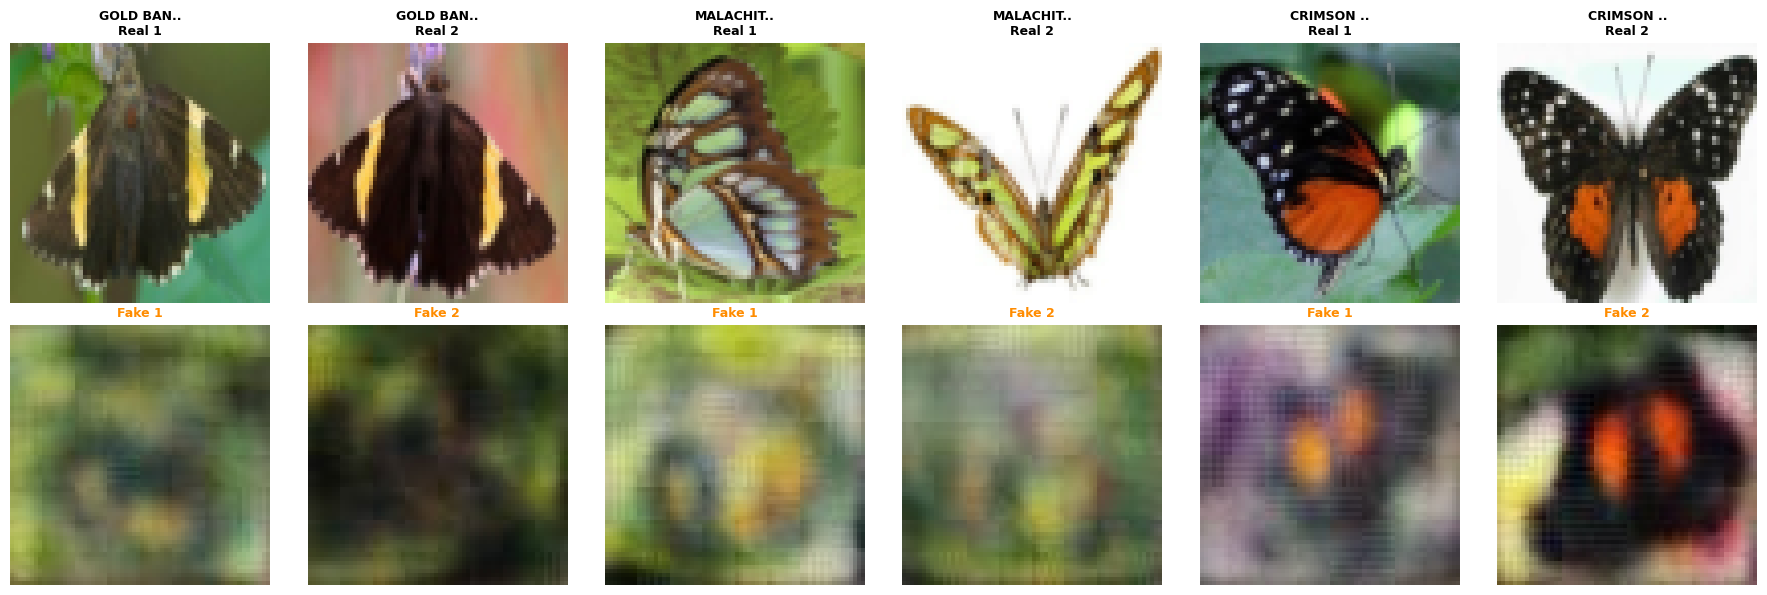

In [206]:
# @title
import matplotlib.pyplot as plt
from torchvision.io import read_image

# Configuração do Grid: 2 linhas (Real, Fake) x 6 colunas (3 classes * 2 amostras)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
print("\n" + "="*80)
print(f"{'INSPEÇÃO VISUAL: REAL (LINHA 1) vs RECONSTRUÇÃO (LINHA 2)':^80}")
print("="*80)

col_idx = 0

for cls in classes_alvo:
    class_suffix = cls.replace(" ", "_")
    folder_sinteticas = os.path.join(diretorio_imagens_sinteticas,'AE', class_suffix)

    images_reais, _ = next(iter(val_loaders_ae[cls]))

    if os.path.exists(folder_sinteticas):
        arquivos = sorted(os.listdir(folder_sinteticas))
        paths_sinteticas = [
            os.path.join(folder_sinteticas, f)
            for f in arquivos if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
    else:
        paths_sinteticas = []

    if len(paths_sinteticas) < 2:
        continue

    for i in range(2):
        # --- LINHA 1: REAL ---
        img_real = images_reais[i].cpu().permute(1, 2, 0).numpy()
        img_real = (img_real - img_real.min()) / (img_real.max() - img_real.min() + 1e-8)

        axes[0, col_idx].imshow(img_real)
        axes[0, col_idx].set_title(f"{cls[:8]}..\nReal {i+1}", fontsize=9, fontweight='bold')
        axes[0, col_idx].axis('off')

        # --- LINHA 2: FAKE ---
        img_fake_tensor = read_image(paths_sinteticas[i]).to(torch.float32) / 255.0
        img_fake = img_fake_tensor.permute(1, 2, 0).numpy()

        axes[1, col_idx].imshow(img_fake)
        axes[1, col_idx].set_title(f"Fake {i+1}", fontsize=9, color='darkorange', fontweight='bold')
        axes[1, col_idx].axis('off')

        col_idx += 1

plt.tight_layout()
plt.show()
print("="*80)

In [80]:
#Juntando os datasets e treinando novamente com as imagens do AE

from torch.utils.data import ConcatDataset


# 1. Função para criar o DF das sintéticas com caminhos absolutos
def criar_df_sinteticas(dir_sinteticas):
    dados = []
    # Caminho base que será usado para construir o caminho absoluto
    base_sinteticas = dir_sinteticas

    for cls in os.listdir(os.path.join(base_sinteticas, 'AE')):
        folder = os.path.join(base_sinteticas, 'AE', cls)
        if os.path.isdir(folder):
            for f in os.listdir(folder):
                if f.lower().endswith(('.jpg', '.png')):
                    dados.append({
                        'filename': os.path.join(folder, f),
                        'label': cls
                    })
    return pd.DataFrame(dados)

# 2. Criar o Dataset das sintéticas
df_sinteticas = criar_df_sinteticas(diretorio_imagens_sinteticas)
ds_sintetico = ButterflyDataset(df=df_sinteticas, img_dir='', transform=train_transform)

# tentativa de reduzir sinteticas - nao mudou a acc
# df_sinteticas = selecionar_top_10_e_criar_df(os.path.join(diretorio_imagens_sinteticas, 'AE'))
# ds_sintetico = ButterflyDataset(df=df_sinteticas, img_dir='', transform=train_transform)

# 3. Concatenar com o seu ds_train original
ds_final = ConcatDataset([train_dataset, ds_sintetico])

# 4. Criar o novo loader com o dataset concatenado
train_loader_final = DataLoader(
    ds_final,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True
)

In [86]:
# # 4. Treino do zero
# Carregar/Treinar Baseline
print("=== CNN + AE ===")

# n_classes = len(dataset.classes)
model_CNN_AE = BaselineCNN(num_classes=cfg.NUM_CLASSES).to(cfg.DEVICE)
optimizer = torch.optim.Adam(model_CNN_AE.parameters(), lr=cfg.CNN_LR) ### lr=0.001
criterion = nn.CrossEntropyLoss()

model_CNN_AE, CNN_AE_history, CNN_AE_val_acc, CNN_AE_test_acc = train_classifier(
    model_CNN_AE, train_loader_final, val_loader, test_loader, optimizer, criterion, cfg)

print("\n=== RESULTADO CNN + AE ===")

print(f"Melhor Val Acc: {CNN_AE_val_acc:.4f}")

print(f"Test Acc: {CNN_AE_test_acc:.4f}")



=== CNN + AE ===

[INFO] Iniciando treinamento da CNN...

Epoch [1/120] | Train Loss: 4.2698 | Train Acc: 2.43% | Val Loss: 4.1933 | Val Acc: 3.21%
Epoch [2/120] | Train Loss: 4.0891 | Train Acc: 3.49% | Val Loss: 3.9194 | Val Acc: 5.26%
Epoch [3/120] | Train Loss: 3.9688 | Train Acc: 4.61% | Val Loss: 3.8486 | Val Acc: 5.26%
Epoch [4/120] | Train Loss: 3.8650 | Train Acc: 4.44% | Val Loss: 4.1444 | Val Acc: 4.74%
Epoch [5/120] | Train Loss: 3.7614 | Train Acc: 5.42% | Val Loss: 3.5787 | Val Acc: 7.69%
Epoch [6/120] | Train Loss: 3.6597 | Train Acc: 6.92% | Val Loss: 3.3906 | Val Acc: 11.41%
Epoch [7/120] | Train Loss: 3.5459 | Train Acc: 8.09% | Val Loss: 3.3903 | Val Acc: 13.85%
Epoch [8/120] | Train Loss: 3.5008 | Train Acc: 8.23% | Val Loss: 3.6629 | Val Acc: 8.21%
Epoch [9/120] | Train Loss: 3.4095 | Train Acc: 10.25% | Val Loss: 3.1567 | Val Acc: 16.03%
Epoch [10/120] | Train Loss: 3.3817 | Train Acc: 10.63% | Val Loss: 3.1905 | Val Acc: 13.72%
Epoch [11/120] | Train Loss: 3.2881

TENTATIVA COM GAN

In [27]:
def get_gan_loader_for_class(df, class_name, transform, cfg):
    # Filtra apenas a classe desejada
    df_class = df[df['label'] == class_name].copy()
    dataset = ButterflyDataset(df=df_class, img_dir=img_dir, transform=transform)

    return DataLoader(
        dataset,
        batch_size=cfg.BATCH_SIZE,
        shuffle=True,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=True,
        drop_last=True
    )

In [34]:
# TREINANDO COM A GAN basica
##### Treinando o GAN

print("=== INICIANDO PIPELINE DE TREINAMENTO DO GANS ===")

gan_histories = {}

for cls in classes_alvo:
    print(f"\n{'='*70}\n PROCESSANDO CLASSE: {cls}\n{'='*70}")

    # 1. Cria o loader específico para esta classe
    df_cls = df_train[df_train['label'] == cls].copy()
    dataset_cls = ButterflyDataset(df=df_cls, img_dir=img_dir, transform=gan_transform)
    loader_cls = DataLoader(
        dataset_cls,
        batch_size=cfg.BATCH_SIZE,
        shuffle=True,
        num_workers=cfg.NUM_WORKERS,
        pin_memory=usar_pin_memory,
        drop_last=True
    )

    # 2. INSTANCIAMENTO E INICIALIZAÇÃO - usando um base pq o puro estourou
    generator = Generator64().to(cfg.DEVICE)
    gen_checkpoint = torch.load("best_gan_gen_base.pth", map_location=cfg.DEVICE)
    generator.load_state_dict(gen_checkpoint)

    discriminator = Discriminator64().to(cfg.DEVICE)
    disc_checkpoint = torch.load("best_gan_disc_base.pth", map_location=cfg.DEVICE)
    discriminator.load_state_dict(disc_checkpoint)

    # generator.apply(weights_init)
    # discriminator.apply(weights_init)

    # 3. OTIMIZADORES (Desbalancear - evitar colapso)
    opt_g = torch.optim.Adam(generator.parameters(), lr=0.0004, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=0.0001, betas=(0.5, 0.999))

    # 4. TREINO COM O LOADER ESPECÍFICO
    generator, discriminator, gan_history = train_pure_gan(
        generator=generator,
        discriminator=discriminator,
        loader=loader_cls,  # AQUI está a mudança chave
        opt_g=opt_g,
        opt_d=opt_d,
        config=cfg,
        target_class=cls,
        force_train=True
    )

    gan_histories[cls] = gan_history

print("\n[OK] Treinamento de todas as classes finalizado.")

=== INICIANDO PIPELINE DE TREINAMENTO DO GANS ===

 PROCESSANDO CLASSE: GOLD BANDED

[INFO] Iniciando treinamento da GAN Pura...

GAN Epoch [1/15] | D Loss: 2.2147 | G Loss: 1.2631 | D Acc R: 37.50% | D Acc F: 56.25%
GAN Epoch [2/15] | D Loss: 2.2276 | G Loss: 0.6164 | D Acc R: 65.62% | D Acc F: 43.75%
GAN Epoch [3/15] | D Loss: 2.3143 | G Loss: 0.8287 | D Acc R: 75.00% | D Acc F: 25.00%
GAN Epoch [4/15] | D Loss: 2.2185 | G Loss: 0.9970 | D Acc R: 62.50% | D Acc F: 34.38%
GAN Epoch [5/15] | D Loss: 1.7908 | G Loss: 1.4290 | D Acc R: 65.62% | D Acc F: 53.12%
GAN Epoch [6/15] | D Loss: 1.9163 | G Loss: 1.1772 | D Acc R: 50.00% | D Acc F: 71.88%
GAN Epoch [7/15] | D Loss: 1.8521 | G Loss: 1.0838 | D Acc R: 68.75% | D Acc F: 43.75%
GAN Epoch [8/15] | D Loss: 1.9115 | G Loss: 1.3159 | D Acc R: 65.62% | D Acc F: 56.25%
GAN Epoch [9/15] | D Loss: 1.8487 | G Loss: 1.6423 | D Acc R: 62.50% | D Acc F: 59.38%
GAN Epoch [10/15] | D Loss: 1.5946 | G Loss: 1.2412 | D Acc R: 62.50% | D Acc F: 75.00%

In [46]:
#gerar samples GAN

for cls in classes_alvo:
    gerar_samples(
        model=generator,
        target_class=cls,
        num_samples=cfg.SAMPLE_PER_CLASS,
        config=cfg,
        output_base_dir=diretorio_imagens_sinteticas,
        model_type='gan',
        loader=orig_loaders_ae[cls]
    )

[INFERENCE] Gerando 47 amostras para [GOLD BANDED] via GAN...
[STATUS] Sucesso: 47 amostras salvas em '/content/drive/MyDrive/UC/ACA/ACA_P2_FBR/dataset_entrega_N3/GOLD_BANDED'.
[INFERENCE] Gerando 47 amostras para [MALACHITE] via GAN...
[STATUS] Sucesso: 47 amostras salvas em '/content/drive/MyDrive/UC/ACA/ACA_P2_FBR/dataset_entrega_N3/MALACHITE'.
[INFERENCE] Gerando 47 amostras para [CRIMSON PATCH] via GAN...
[STATUS] Sucesso: 47 amostras salvas em '/content/drive/MyDrive/UC/ACA/ACA_P2_FBR/dataset_entrega_N3/CRIMSON_PATCH'.


In [47]:
# Avaliando as imagens

metricas_consolidadas = {}

for cls in classes_alvo:
    res = avaliar_metricas_por_classe(
        val_loader_real=val_loaders_ae[cls],
        output_base_dir=os.path.join(diretorio_imagens_sinteticas, 'GAN'),
        target_class=cls,
        device=cfg.DEVICE
    )
    if res:
        metricas_consolidadas[cls] = res

# ======================================================================
# IMPRESSÃO DO RELATÓRIO MATEMÁTICO UNIFICADO
# ======================================================================
print("\n" + "="*95)
print(f"{'AUDITORIA MATEMÁTICA DO DATASET EXPANDIDO (GANS)':^95}")
print("="*95)
print(f"{'Classe Borboleta':<25} | {'FID (↓) [Realismo]':<22} | {'IS (↑) [Diversidade]':<22} | {'SSIM Médio (↑)'}")
print("-"*95)

for cls, metrics in metricas_consolidadas.items():
    print(f"{cls:<25} | {metrics['FID']:<22.4f} | {metrics['IS']:<22.4f} | {metrics['SSIM']:.4f}")

print("="*95)
print("[INFO] FID (Fréchet Inception Distance): Avalia a distância das distribuições das fakes vs reais. Menor é melhor.")
print("[INFO] IS (Inception Score): Mede a qualidade e a variedade das imagens geradas. Maior é melhor.")
print("[INFO] SSIM (Structural Similarity): Mede a fidelidade geométrica pixel a pixel da reconstrução. Próximo a 1.0 é perfeito.")
print("="*95)


[METRICS] Processando métricas para [GOLD BANDED]...

[METRICS] Processando métricas para [MALACHITE]...

[METRICS] Processando métricas para [CRIMSON PATCH]...

                       AUDITORIA MATEMÁTICA DO DATASET EXPANDIDO (GANS)                        
Classe Borboleta          | FID (↓) [Realismo]     | IS (↑) [Diversidade]   | SSIM Médio (↑)
-----------------------------------------------------------------------------------------------
GOLD BANDED               | 357.4062               | 1.0243                 | 0.1171
MALACHITE                 | 381.7978               | 1.0228                 | 0.0839
CRIMSON PATCH             | 355.8174               | 1.0214                 | 0.0939
[INFO] FID (Fréchet Inception Distance): Avalia a distância das distribuições das fakes vs reais. Menor é melhor.
[INFO] IS (Inception Score): Mede a qualidade e a variedade das imagens geradas. Maior é melhor.
[INFO] SSIM (Structural Similarity): Mede a fidelidade geométrica pixel a pixel da rec

In [49]:
#Juntando os datasets e treinando novamente com as imagens do GAN

from torch.utils.data import ConcatDataset


# 1. Função para criar o DF das sintéticas com caminhos absolutos
def criar_df_sinteticas(dir_sinteticas):
    dados = []
    # Caminho base que será usado para construir o caminho absoluto
    # Certifique-se que esta variável aponta para o diretório pai da pasta 'GAN'
    base_sinteticas = dir_sinteticas

    for cls in os.listdir(os.path.join(base_sinteticas, 'GAN')):
        folder = os.path.join(base_sinteticas, 'GAN', cls)
        if os.path.isdir(folder):
            for f in os.listdir(folder):
                if f.lower().endswith(('.jpg', '.png')):
                    dados.append({
                        'filename': os.path.join(folder, f),
                        'label': cls
                    })
    return pd.DataFrame(dados)

# 2. Criar o Dataset das sintéticas
df_sinteticas = criar_df_sinteticas(diretorio_imagens_sinteticas)
ds_sintetico = ButterflyDataset(df=df_sinteticas, img_dir='', transform=train_transform)

# 3. Concatenar com  ds_train
ds_final = ConcatDataset([train_dataset, ds_sintetico])

# 4. Criar o novo loader com o dataset concatenado
train_loader_final = DataLoader(
    ds_final,
    batch_size=cfg.BATCH_SIZE,
    shuffle=True,
    num_workers=cfg.NUM_WORKERS,
    pin_memory=True
)

In [52]:
# # 4. Treino do zero
# Carregar/Treinar Baseline
print("=== CNN + GAN ===")

# n_classes = len(dataset.classes)
model_CNN_GAN = BaselineCNN(num_classes=cfg.NUM_CLASSES).to(cfg.DEVICE)
optimizer = torch.optim.Adam(model_CNN_GAN.parameters(), lr=cfg.CNN_LR) ### lr=0.001
criterion = nn.CrossEntropyLoss()

model_CNN_GAN, CNN_GAN_history, CNN_GAN_val_acc, CNN_GAN_test_acc = train_classifier(
    model_CNN_GAN, train_loader_final, val_loader, test_loader, optimizer, criterion, cfg)

print("\n=== RESULTADO CNN + GAN ===")

print(f"Melhor Val Acc: {CNN_GAN_val_acc:.4f}")

print(f"Test Acc: {CNN_GAN_test_acc:.4f}")

=== CNN + GAN ===

[INFO] Iniciando treinamento da CNN...

Epoch [1/120] | Train Loss: 4.1982 | Train Acc: 3.20% | Val Loss: 4.0826 | Val Acc: 3.08%
Epoch [2/120] | Train Loss: 3.9980 | Train Acc: 3.94% | Val Loss: 4.0462 | Val Acc: 3.59%
Epoch [3/120] | Train Loss: 3.9004 | Train Acc: 4.97% | Val Loss: 3.8768 | Val Acc: 3.21%
Epoch [4/120] | Train Loss: 3.8021 | Train Acc: 5.82% | Val Loss: 3.7680 | Val Acc: 5.90%
Epoch [5/120] | Train Loss: 3.7157 | Train Acc: 6.61% | Val Loss: 3.6326 | Val Acc: 8.46%
Epoch [6/120] | Train Loss: 3.6081 | Train Acc: 7.83% | Val Loss: 3.6120 | Val Acc: 7.05%
Epoch [7/120] | Train Loss: 3.4415 | Train Acc: 10.08% | Val Loss: 3.3329 | Val Acc: 12.05%
Epoch [8/120] | Train Loss: 3.3662 | Train Acc: 11.61% | Val Loss: 3.2291 | Val Acc: 14.23%
Epoch [9/120] | Train Loss: 3.2693 | Train Acc: 12.59% | Val Loss: 3.0405 | Val Acc: 20.26%
Epoch [10/120] | Train Loss: 3.1519 | Train Acc: 14.34% | Val Loss: 3.0226 | Val Acc: 15.38%
Epoch [11/120] | Train Loss: 3.0

TENTATIVA COM VAE - Treino MESTRE total e Finetunning com 3 classes.

In [144]:
# @title
###  ININCIANDO TENTATIVA COM O VAE  ###

# --- 1. TREINO MESTRE ---
# Treina uma única vez para aprender a geometria de "todas as borboletas"
model_master = ButterflyVAE64().to(cfg.DEVICE)
opt_master = torch.optim.Adam(model_master.parameters(), lr=1e-3)

print("\n[PIPELINE] Iniciando Treino Mestre...")
model_master, _ = train_vae(
    model=model_master,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=opt_master,
    config=cfg,
    target_class="MASTER",
    force_train = True
)


[PIPELINE] Iniciando Treino Mestre...


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d54556bdee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d54556bdee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

VAE Epoch 1 | Train_Loss: 7809.60 | Val_Loss: 7788.42 | Train_Acc: 80.22| Val_Acc: 83.28%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d54556bdee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d54556bdee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

VAE Epoch 2 | Train_Loss: 7163.63 | Val_Loss: 7469.64 | Train_Acc: 85.33| Val_Acc: 86.27%


...

VAE Epoch 20 | Train_Loss: 6574.13 | Val_Loss: 7077.59 | Train_Acc: 90.87| Val_Acc: 90.61%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d54556bdee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
       ^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7d54556bdee0>
^^Traceback (most recent call last):
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
^    ^self._shutdown_workers()^
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^^    
if w.is_alive(): 
    File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
      assert self._parent_pid == os.getpid(), 'can only test a child process'  
^^  ^ ^^ ^^ ^  ^^  ^ ^ 
^  File "/us

VAE Epoch 21 | Train_Loss: 6572.58 | Val_Loss: 7079.01 | Train_Acc: 90.98| Val_Acc: 90.63%


Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d54556bdee0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
 Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7d54556bdee0> 
 Traceback (most recent call last):
    File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
     self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
^    if w.is_alive():^^
^ ^ ^ ^ ^^ ^ 
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
 ^    assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^   ^ ^  ^^  ^  ^^^^^^
^^  File 

VAE Epoch 22 | Train_Loss: 6569.13 | Val_Loss: 7113.13 | Train_Acc: 91.01| Val_Acc: 90.22%
VAE Epoch 23 | Train_Loss: 6575.53 | Val_Loss: 7072.29 | Train_Acc: 91.06| Val_Acc: 90.76%
VAE Epoch 24 | Train_Loss: 6556.83 | Val_Loss: 7066.34 | Train_Acc: 91.09| Val_Acc: 90.91%
VAE Epoch 25 | Train_Loss: 6547.47 | Val_Loss: 7071.73 | Train_Acc: 91.13| Val_Acc: 90.86%
VAE Epoch 26 | Train_Loss: 6567.02 | Val_Loss: 7064.66 | Train_Acc: 91.17| Val_Acc: 90.91%
VAE Epoch 27 | Train_Loss: 6562.70 | Val_Loss: 7056.46 | Train_Acc: 91.24| Val_Acc: 90.99%
VAE Epoch 28 | Train_Loss: 6543.76 | Val_Loss: 7058.09 | Train_Acc: 91.28| Val_Acc: 90.91%
VAE Epoch 29 | Train_Loss: 6542.42 | Val_Loss: 7051.58 | Train_Acc: 91.29| Val_Acc: 90.99%
VAE Epoch 30 | Train_Loss: 6542.76 | Val_Loss: 7051.13 | Train_Acc: 91.33| Val_Acc: 91.04%
VAE Epoch 31 | Train_Loss: 6538.68 | Val_Loss: 7055.13 | Train_Acc: 91.31| Val_Acc: 90.91%
VAE Epoch 32 | Train_Loss: 6534.64 | Val_Loss: 7049.65 | Train_Acc: 91.42| Val_Acc: 91.05%

In [149]:
# @title
# --- 2. REFINAMENTO ESPECIALISTA (Ajuste fino) ---
# Com 50 imagens, 10 épocas com LR baixo é mais que suficiente
ae_histories = {}

for cls in classes_alvo:
    print(f"\n[PIPELINE] Refinando classe (Especialista): {cls}")

    # 1. Carrega o Mestre
    model_vae = ButterflyVAE64().to(cfg.DEVICE)
    model_vae.load_state_dict(torch.load("best_vae_MASTER.pth"))

    # 1. Congelar Encoder
    for param in model_vae.encoder.parameters():
        param.requires_grad = False

    # 2. Definir parâmetros treináveis (Pescoço + Decoder)
    # Incluindo fc_mu, fc_var, fc_decode e toda a rede de reconstrução (decoder)
    params_to_update = list(model_vae.fc_mu.parameters()) + \
                      list(model_vae.fc_var.parameters()) + \
                      list(model_vae.fc_decode.parameters()) + \
                      list(model_vae.decoder.parameters())

    # 3. Otimizador focado
    opt_fine = torch.optim.Adam(params_to_update, lr=1e-5)


    # 4. Treina o Especialista com o Encoder travado
    model_vae, hist = train_vae(
        model=model_vae,
        train_loader=train_loaders_ae[cls],
        val_loader=val_loaders_ae[cls],
        optimizer=opt_fine,
        config=cfg,
        target_class=cls
    )

    ae_histories[cls] = hist

print("\n[OK] Pipeline concluído. O Mestre e os Especialistas estão prontos para a geração.")


[PIPELINE] Refinando classe (Especialista): GOLD BANDED
VAE Epoch 1 | Train_Loss: 6566.95 | Val_Loss: 7132.94 | Train_Acc: 92.73| Val_Acc: 92.80%
VAE Epoch 2 | Train_Loss: 6559.89 | Val_Loss: 7129.28 | Train_Acc: 92.68| Val_Acc: 92.76%
VAE Epoch 3 | Train_Loss: 6574.76 | Val_Loss: 7127.32 | Train_Acc: 92.85| Val_Acc: 92.83%
VAE Epoch 4 | Train_Loss: 6469.60 | Val_Loss: 7129.18 | Train_Acc: 92.73| Val_Acc: 92.81%
VAE Epoch 5 | Train_Loss: 6473.64 | Val_Loss: 7130.44 | Train_Acc: 92.79| Val_Acc: 92.84%
VAE Epoch 6 | Train_Loss: 6505.83 | Val_Loss: 7127.34 | Train_Acc: 92.89| Val_Acc: 92.83%
VAE Epoch 7 | Train_Loss: 6564.61 | Val_Loss: 7127.16 | Train_Acc: 92.98| Val_Acc: 92.83%
VAE Epoch 8 | Train_Loss: 6492.57 | Val_Loss: 7133.26 | Train_Acc: 92.69| Val_Acc: 92.75%
VAE Epoch 9 | Train_Loss: 6505.47 | Val_Loss: 7128.51 | Train_Acc: 92.53| Val_Acc: 92.85%
VAE Epoch 10 | Train_Loss: 6598.36 | Val_Loss: 7130.04 | Train_Acc: 92.99| Val_Acc: 92.80%
VAE Epoch 11 | Train_Loss: 6491.06 | Val_L

In [184]:
# @title
# Gerando imagens VAE

for cls in classes_alvo:
    # 1. Carrega o modelo especialista treinado daquela classe
    model_vae = ButterflyVAE64().to(cfg.DEVICE)
    model_vae.load_state_dict(torch.load(f"best_vae_{cls.replace(' ', '_')}.pth"))

    # 2. Chama a função de geração (Sem o argumento 'loader')
    gerar_samples(
        model=model_vae,
        target_class=cls,
        num_samples=47,  # ou a quantidade que desejar
        config=cfg,
        output_base_dir=diretorio_imagens_sinteticas,
        model_type='vae'
    )




[INFERENCE] Gerando 47 amostras para [GOLD BANDED] via VAE...
[STATUS] Sucesso: 47 amostras salvas em '/content/drive/MyDrive/UC/ACA/ACA_P2_FBR/dataset_entrega_N3/GOLD_BANDED'.
[INFERENCE] Gerando 47 amostras para [MALACHITE] via VAE...
[STATUS] Sucesso: 47 amostras salvas em '/content/drive/MyDrive/UC/ACA/ACA_P2_FBR/dataset_entrega_N3/MALACHITE'.
[INFERENCE] Gerando 47 amostras para [CRIMSON PATCH] via VAE...
[STATUS] Sucesso: 47 amostras salvas em '/content/drive/MyDrive/UC/ACA/ACA_P2_FBR/dataset_entrega_N3/CRIMSON_PATCH'.



           INSPEÇÃO VISUAL: REAL (LINHA 1) vs RECONSTRUÇÃO (LINHA 2)            


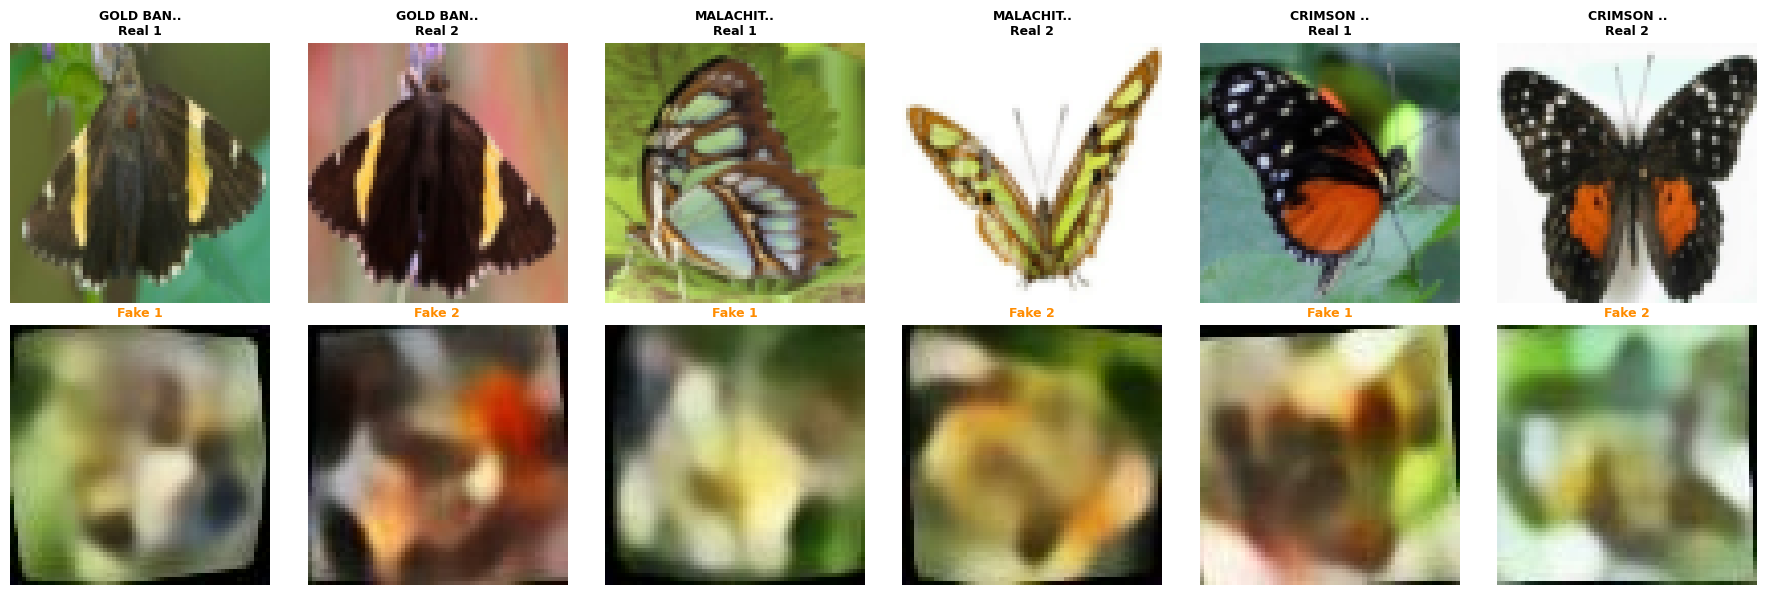

In [16]:
# @title
import matplotlib.pyplot as plt
from torchvision.io import read_image

# Configuração do Grid: 2 linhas (Real, Fake) x 6 colunas (3 classes * 2 amostras)
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
print("\n" + "="*80)
print(f"{'INSPEÇÃO VISUAL: REAL (LINHA 1) vs RECONSTRUÇÃO (LINHA 2)':^80}")
print("="*80)

col_idx = 0

for cls in classes_alvo:
    class_suffix = cls.replace(" ", "_")
    folder_sinteticas = os.path.join(diretorio_imagens_sinteticas,'VAE', class_suffix)

    images_reais, _ = next(iter(val_loaders_ae[cls]))

    if os.path.exists(folder_sinteticas):
        arquivos = sorted(os.listdir(folder_sinteticas))
        paths_sinteticas = [
            os.path.join(folder_sinteticas, f)
            for f in arquivos if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ]
    else:
        paths_sinteticas = []

    if len(paths_sinteticas) < 2:
        continue

    for i in range(2):
        # --- LINHA 1: REAL ---
        img_real = images_reais[i].cpu().permute(1, 2, 0).numpy()
        img_real = (img_real - img_real.min()) / (img_real.max() - img_real.min() + 1e-8)

        axes[0, col_idx].imshow(img_real)
        axes[0, col_idx].set_title(f"{cls[:8]}..\nReal {i+1}", fontsize=9, fontweight='bold')
        axes[0, col_idx].axis('off')

        # --- LINHA 2: FAKE ---
        img_fake_tensor = read_image(paths_sinteticas[i]).to(torch.float32) / 255.0
        img_fake = img_fake_tensor.permute(1, 2, 0).numpy()

        axes[1, col_idx].imshow(img_fake)
        axes[1, col_idx].set_title(f"Fake {i+1}", fontsize=9, color='darkorange', fontweight='bold')
        axes[1, col_idx].axis('off')

        col_idx += 1

plt.tight_layout()
plt.show()
print("="*80)

In [18]:
# @title
# Avaliando as imagens

metricas_consolidadas = {}

for cls in classes_alvo:
    res = avaliar_metricas_por_classe(
        val_loader_real=val_loaders_ae[cls],
        output_base_dir=os.path.join(diretorio_imagens_sinteticas, 'VAE'),
        target_class=cls,
        device=cfg.DEVICE
    )
    if res:
        metricas_consolidadas[cls] = res

# ======================================================================
# IMPRESSÃO DO RELATÓRIO MATEMÁTICO UNIFICADO
# ======================================================================
print("\n" + "="*95)
print(f"{'AUDITORIA MATEMÁTICA DO DATASET EXPANDIDO (VAE)':^95}")
print("="*95)
print(f"{'Classe Borboleta':<25} | {'FID (↓) [Realismo]':<22} | {'IS (↑) [Diversidade]':<22} | {'SSIM Médio (↑)'}")
print("-"*95)

for cls, metrics in metricas_consolidadas.items():
    print(f"{cls:<25} | {metrics['FID']:<22.4f} | {metrics['IS']:<22.4f} | {metrics['SSIM']:.4f}")

print("="*95)
print("[INFO] FID (Fréchet Inception Distance): Avalia a distância das distribuições das fakes vs reais. Menor é melhor.")
print("[INFO] IS (Inception Score): Mede a qualidade e a variedade das imagens geradas. Maior é melhor.")
print("[INFO] SSIM (Structural Similarity): Mede a fidelidade geométrica pixel a pixel da reconstrução. Próximo a 1.0 é perfeito.")
print("="*95)


                        AUDITORIA MATEMÁTICA DO DATASET EXPANDIDO (VAE)                        
Classe Borboleta          | FID (↓) [Realismo]     | IS (↑) [Diversidade]   | SSIM Médio (↑)
-----------------------------------------------------------------------------------------------
GOLD BANDED               | 395.8435               | 1.0504                 | 0.0874
MALACHITE                 | 369.9059               | 1.0573                 | 0.0695
CRIMSON PATCH             | 387.0453               | 1.0560                 | 0.0844
[INFO] FID (Fréchet Inception Distance): Avalia a distância das distribuições das fakes vs reais. Menor é melhor.
[INFO] IS (Inception Score): Mede a qualidade e a variedade das imagens geradas. Maior é melhor.
[INFO] SSIM (Structural Similarity): Mede a fidelidade geométrica pixel a pixel da reconstrução. Próximo a 1.0 é perfeito.


CONSIDERANDO A INSPECAO VISUAL E AS METRICAS PIORES QUE O AE, Nao seguiremos com o VAE.

In [58]:
# TESTE FINAL E SUBMISSAO
img_dir_testfinal = os.path.join(path, 'test')

# Lista e ordena os arquivos da pasta test
testfinal_images = sorted([f for f in os.listdir(img_dir_testfinal) if f.endswith(('.jpg'))])

# Criamos o DataFrame de input contendo um label real conhecido
um_label_valido = list(train_dataset.class_to_idx.keys())[0]

df_submission_input = pd.DataFrame({
    'filename': testfinal_images,
    'label': [um_label_valido] * len(testfinal_images)
})

testfinal_dataset = ButterflyDataset(
    df=df_submission_input,
    img_dir=img_dir_testfinal,
    transform=val_transform
)

testfinal_loader = DataLoader(
    testfinal_dataset,
    batch_size=cfg.BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

# Dicionário reverso para converter o número da predição (0-74) de volta para o texto por extenso
idx_to_class = {idx: cls_name for cls_name, idx in train_dataset.class_to_idx.items()}

# carrega modelo
device = torch.device("cpu")
model = BaselineCNN(num_classes=cfg.NUM_CLASSES)
model.load_state_dict(torch.load('best_classifier_CNN_GAN.pth', map_location=device))
model.eval()

submission_records = []

print(f"[INFO] Avaliando {len(testfinal_images)} imagens diretamente no pipeline ativo.")

with torch.no_grad():
    for batch_idx, (images, _) in enumerate(testfinal_loader):
        images = images.to(device)
        outputs = model(images)

        # Coleta o índice inteiro predito pelo classificador
        _, preds = torch.max(outputs, 1)

        # Recupera o bloco de nomes de arquivos correspondentes a este batch
        start_idx = batch_idx * cfg.BATCH_SIZE
        end_idx = start_idx + len(images)
        batch_files = testfinal_images[start_idx:end_idx]

        for img_name, pred in zip(batch_files, preds):
            # Traduz o ID numérico para o nome da string por extenso cadastrada no treino
            nome_classe_textual = idx_to_class[pred.item()]

            submission_records.append({
                "filename": img_name,        # Ex: Image_0.jpg
                "label": nome_classe_textual # Ex: CLOUDED SULPHUR
            })

# gera arquivo
df_final_submission = pd.DataFrame(submission_records)
df_final_submission.to_csv('submission_N3_CNN_3C_GAN.csv', index=False)

print("\n=== PRONTO ===")
print("O arquivo 'submission_N3_CNN_3C_GAN.csv' foi gerado usando 100% dos seus objetos originais.")

[INFO] Avaliando 1300 imagens diretamente no pipeline ativo.

=== PRONTO ===
O arquivo 'submission_N3_CNN_3C_GAN.csv' foi gerado usando 100% dos seus objetos originais.


In [78]:
# Tentativa post-mortem de melhorar a performance inserindo apenas 20% do dataset sintetico - Nao mudou nada.
def selecionar_top_10_e_criar_df(origem):
    dados = []

    # Percorre cada classe
    for cls in os.listdir(origem):
        folder = os.path.join(origem, cls)
        if os.path.isdir(folder):
            arquivos = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png'))]

            # Se tivermos mais de 10, aplicamos o filtro de qualidade
            if len(arquivos) > 10:
                # Carrega imagens da classe para tensor
                tensors = [ToTensor()(Image.open(os.path.join(folder, f)).convert('RGB').resize((128, 128))).view(-1) for f in arquivos]
                stack = torch.stack(tensors)
                media = stack.mean(dim=0)
                distancias = torch.norm(stack - media, dim=1)

                # Pega os 10 índices com menor distância
                _, indices = torch.topk(distancias, 10, largest=False)
                selecionados = [arquivos[i] for i in indices]
            else:
                selecionados = arquivos

            # Adiciona ao DF apenas os selecionados
            for f in selecionados:
                dados.append({'filename': os.path.join(folder, f), 'label': cls})

    return pd.DataFrame(dados)